# Notebook 02 — Model Training & Hyperparameter Tuning (V2)
**Thesis**: A Prescriptive and Explainable Hybrid ML Framework for T2D Risk Prediction
**Dataset**: DiaHealth (single dataset)

### Models
- XGBoost + Optuna (100 trials, early stopping)
- LightGBM + Optuna (100 trials, early stopping)
- CatBoost + Optuna (100 trials, early stopping)
- AutoGluon (15-min best_quality)

### Checkpoint Strategy
Each model has its own checkpoint (`nb02_xgb_diahealth.pkl`, etc.).
If the session crashes, completed models are not re-trained.


In [ ]:
# ============================================================
# 1. INSTALL
# ============================================================
!pip install -q "scipy>=1.14.0,<1.17" "seaborn>=0.13.2" --upgrade
!pip install -q xgboost lightgbm catboost autogluon optuna joblib scikit-learn matplotlib

# Restart so upgraded scipy is loaded fresh into memory



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import shutil
import joblib
import optuna
import json

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, brier_score_loss, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, train_test_split as _tts

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
RANDOM_STATE    = 42
N_OPTUNA_TRIALS = 100

print('All imports successful.')


All imports successful.


## 2. Load Processed Data

In [ ]:
# ============================================================
# 2. LOAD PROCESSED DATA
# ============================================================
EXP_DIR       = '/kaggle/working/exp_v2'
PROCESSED_DIR = os.path.join(EXP_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(EXP_DIR, 'models')
RESULTS_DIR   = os.path.join(EXP_DIR, 'results')
CKPT_DIR      = os.path.join(EXP_DIR, 'checkpoints')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,    exist_ok=True)

meta = joblib.load(os.path.join(PROCESSED_DIR, 'meta.pkl'))
print(f'Version: {meta.get("version","?")}  |  Datasets: {meta["datasets"]}')

d = joblib.load(os.path.join(PROCESSED_DIR, 'diahealth_processed.pkl'))

# Use resampled training set (handles class imbalance)
X_train = d['X_train_res_boruta']
y_train = d['y_train_res']
# Use original (non-resampled) test set for unbiased evaluation
X_test  = d['X_test_boruta']
y_test  = d['y_test']

TARGET_COL = d['target_col']
FEATURES   = d['feature_names_boruta']

print(f'Train: {X_train.shape}  Positive rate: {y_train.mean():.2%}')
print(f'Test : {X_test.shape}   Positive rate: {y_test.mean():.2%}')
print(f'Features ({len(FEATURES)}): {FEATURES}')


Version: v2  |  Datasets: ['diahealth']
Train: (8148, 16)  Positive rate: 50.00%
Test : (1088, 16)   Positive rate: 6.34%
Features (16): ['age', 'gender', 'pulse_rate', 'systolic_bp', 'diastolic_bp', 'glucose', 'weight', 'bmi', 'hypertensive', 'bp_ratio', 'pulse_pressure', 'bmi_age', 'glucose_bmi', 'cardio_risk', 'family_hypertension', 'family_risk']


## 3. Evaluation Helpers

In [ ]:
# ============================================================
# 3. EVALUATION HELPERS
# ============================================================

def evaluate_model(model, X_test, y_test, model_name='Model'):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = {
        'model':     model_name,
        'dataset':   'DIAHEALTH',
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'auc_roc':   roc_auc_score(y_test, y_prob),
        'auc_pr':    average_precision_score(y_test, y_prob),
        'brier':     brier_score_loss(y_test, y_prob),
    }
    print(f'  {model_name:12s} | AUC={metrics["auc_roc"]:.4f} '
          f'F1={metrics["f1"]:.4f} Acc={metrics["accuracy"]:.4f} '
          f'Brier={metrics["brier"]:.4f}')
    return metrics


def plot_roc_pr(models_dict, X_test, y_test, title='DiaHealth'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, model in models_dict.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title(f'{title} — ROC Curve'); axes[0].legend()
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{title} — PR Curve'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'diahealth_roc_pr.png'), dpi=150)
    plt.show()

print('Helpers defined.')


Helpers defined.


## 4. XGBoost + Optuna (checkpoint)

In [ ]:
# ============================================================
# 4. XGBOOST WITH OPTUNA
# ============================================================
CKPT_XGB = os.path.join(CKPT_DIR, 'nb02_xgb_diahealth.pkl')

def xgb_objective(trial, X_tr, y_tr):
    n_pos = (y_tr == 1).sum(); n_neg = (y_tr == 0).sum()
    scale = n_neg / max(n_pos, 1)
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 2000),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight',
                                                max(1.0, scale * 0.5),
                                                min(20.0, scale * 2.0)),
        'eval_metric': 'logloss',
        'early_stopping_rounds': 50,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'tree_method': 'hist',
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for ti, vi in cv.split(X_tr, y_tr):
        m = xgb.XGBClassifier(**params)
        m.fit(X_tr.iloc[ti], y_tr.iloc[ti],
              eval_set=[(X_tr.iloc[vi], y_tr.iloc[vi])], verbose=False)
        scores.append(roc_auc_score(y_tr.iloc[vi], m.predict_proba(X_tr.iloc[vi])[:, 1]))
    return np.mean(scores)

if os.path.exists(CKPT_XGB):
    ckpt = joblib.load(CKPT_XGB)
    xgb_model = ckpt['model']
    xgb_metrics = ckpt['metrics']
    print(f'XGBoost loaded from checkpoint (AUC={xgb_metrics["auc_roc"]:.4f})')
else:
    print('Running XGBoost Optuna tuning...')
    study = optuna.create_study(direction='maximize', study_name='xgb_diahealth')
    study.optimize(lambda t: xgb_objective(t, X_train, y_train),
                   n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
    bp = study.best_params
    bp.update({'eval_metric': 'logloss', 'early_stopping_rounds': 50,
               'random_state': RANDOM_STATE, 'n_jobs': -1, 'tree_method': 'hist'})
    xgb_model = xgb.XGBClassifier(**bp)
    X_tr2, X_es2, y_tr2, y_es2 = _tts(X_train, y_train, test_size=0.1,
                                        stratify=y_train, random_state=RANDOM_STATE)
    xgb_model.fit(X_tr2, y_tr2, eval_set=[(X_es2, y_es2)], verbose=0)
    xgb_metrics = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
    xgb_metrics['best_params'] = bp
    joblib.dump({'model': xgb_model, 'metrics': xgb_metrics}, CKPT_XGB)
    print(f'  Checkpoint saved -> {CKPT_XGB}')

print('XGBoost done.')


XGBoost loaded from checkpoint (AUC=0.8203)
XGBoost done.


## 5. LightGBM + Optuna (checkpoint)

In [ ]:
# ============================================================
# 5. LIGHTGBM WITH OPTUNA
# ============================================================
CKPT_LGB = os.path.join(CKPT_DIR, 'nb02_lgb_diahealth.pkl')

def lgb_objective(trial, X_tr, y_tr):
    n_pos = (y_tr == 1).sum(); n_neg = (y_tr == 0).sum()
    scale = n_neg / max(n_pos, 1)
    params = {
        'n_estimators':        trial.suggest_int('n_estimators', 200, 2000),
        'max_depth':           trial.suggest_int('max_depth', 3, 12),
        'learning_rate':       trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves':          trial.suggest_int('num_leaves', 20, 300),
        'subsample':           trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':    trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':           trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':          trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_samples':   trial.suggest_int('min_child_samples', 5, 100),
        'scale_pos_weight':    trial.suggest_float('scale_pos_weight',
                                                   max(1.0, scale * 0.5),
                                                   min(20.0, scale * 2.0)),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': -1,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for ti, vi in cv.split(X_tr, y_tr):
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr.iloc[ti], y_tr.iloc[ti],
              eval_set=[(X_tr.iloc[vi], y_tr.iloc[vi])],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(-1)])
        scores.append(roc_auc_score(y_tr.iloc[vi], m.predict_proba(X_tr.iloc[vi])[:, 1]))
    return np.mean(scores)

if os.path.exists(CKPT_LGB):
    ckpt = joblib.load(CKPT_LGB)
    lgb_model = ckpt['model']
    lgb_metrics = ckpt['metrics']
    print(f'LightGBM loaded from checkpoint (AUC={lgb_metrics["auc_roc"]:.4f})')
else:
    print('Running LightGBM Optuna tuning...')
    study = optuna.create_study(direction='maximize', study_name='lgb_diahealth')
    study.optimize(lambda t: lgb_objective(t, X_train, y_train),
                   n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
    bp = study.best_params
    bp.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbosity': -1})
    lgb_model = lgb.LGBMClassifier(**bp)
    X_tr2, X_es2, y_tr2, y_es2 = _tts(X_train, y_train, test_size=0.1,
                                        stratify=y_train, random_state=RANDOM_STATE)
    lgb_model.fit(X_tr2, y_tr2,
                  eval_set=[(X_es2, y_es2)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(-1)])
    lgb_metrics = evaluate_model(lgb_model, X_test, y_test, 'LightGBM')
    lgb_metrics['best_params'] = bp
    joblib.dump({'model': lgb_model, 'metrics': lgb_metrics}, CKPT_LGB)
    print(f'  Checkpoint saved -> {CKPT_LGB}')

print('LightGBM done.')


LightGBM loaded from checkpoint (AUC=0.8197)
LightGBM done.


## 6. CatBoost + Optuna (checkpoint)

In [ ]:
# ============================================================
# 6. CATBOOST WITH OPTUNA
# ============================================================
CKPT_CAT = os.path.join(CKPT_DIR, 'nb02_cat_diahealth.pkl')

def cat_objective(trial, X_tr, y_tr):
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 2000),
        'depth':         trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'border_count':  trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': 'Balanced',
        'random_seed': RANDOM_STATE,
        'verbose': 0,
        'allow_writing_files': False,
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for ti, vi in cv.split(X_tr, y_tr):
        m = CatBoostClassifier(**params)
        m.fit(X_tr.iloc[ti], y_tr.iloc[ti],
              eval_set=(X_tr.iloc[vi], y_tr.iloc[vi]),
              early_stopping_rounds=50, verbose=0)
        scores.append(roc_auc_score(y_tr.iloc[vi], m.predict_proba(X_tr.iloc[vi])[:, 1]))
    return np.mean(scores)

if os.path.exists(CKPT_CAT):
    ckpt = joblib.load(CKPT_CAT)
    cat_model = ckpt['model']
    cat_metrics = ckpt['metrics']
    print(f'CatBoost loaded from checkpoint (AUC={cat_metrics["auc_roc"]:.4f})')
else:
    print('Running CatBoost Optuna tuning...')
    study = optuna.create_study(direction='maximize', study_name='cat_diahealth')
    study.optimize(lambda t: cat_objective(t, X_train, y_train),
                   n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
    bp = study.best_params
    bp.update({'auto_class_weights': 'Balanced', 'random_seed': RANDOM_STATE,
               'verbose': 0, 'allow_writing_files': False})
    cat_model = CatBoostClassifier(**bp)
    X_tr2, X_es2, y_tr2, y_es2 = _tts(X_train, y_train, test_size=0.1,
                                        stratify=y_train, random_state=RANDOM_STATE)
    cat_model.fit(X_tr2, y_tr2, eval_set=(X_es2, y_es2),
                  early_stopping_rounds=50, verbose=0)
    cat_metrics = evaluate_model(cat_model, X_test, y_test, 'CatBoost')
    cat_metrics['best_params'] = bp
    joblib.dump({'model': cat_model, 'metrics': cat_metrics}, CKPT_CAT)
    print(f'  Checkpoint saved -> {CKPT_CAT}')

print('CatBoost done.')


CatBoost loaded from checkpoint (AUC=0.8085)
CatBoost done.


## 7. AutoGluon Ensemble (checkpoint)

In [ ]:
# ============================================================
# 7. AUTOGLUON ENSEMBLE
# ============================================================
from autogluon.tabular import TabularPredictor

CKPT_AG  = os.path.join(CKPT_DIR, 'nb02_ag_diahealth.pkl')
AG_PATH  = os.path.join(MODELS_DIR, 'autogluon_diahealth')

if os.path.exists(CKPT_AG) and os.path.exists(AG_PATH):
    ckpt = joblib.load(CKPT_AG)
    ag_model   = TabularPredictor.load(AG_PATH)
    ag_metrics = ckpt['metrics']
    print(f'AutoGluon loaded from checkpoint (AUC={ag_metrics["auc_roc"]:.4f})')
else:
    print('Training AutoGluon ensemble (15 min time limit)...')
    if os.path.exists(AG_PATH):
        shutil.rmtree(AG_PATH)

    # Reconstruct original (non-resampled) train for AutoGluon
    d_orig = joblib.load(os.path.join(PROCESSED_DIR, 'diahealth_processed.pkl'))
    X_train_orig = d_orig['X_train_boruta']
    y_train_orig = d_orig['y_train']

    train_df = X_train_orig.copy()
    train_df[TARGET_COL] = y_train_orig.values
    test_df  = X_test.copy()
    test_df[TARGET_COL]  = y_test.values

    ag_model = TabularPredictor(
        label=TARGET_COL, eval_metric='roc_auc', path=AG_PATH,
    ).fit(
        train_data=train_df,
        time_limit=900,
        presets='best_quality',
        num_bag_folds=5,
        verbosity=1,
    )

    y_pred = ag_model.predict(test_df.drop(columns=[TARGET_COL]))
    y_prob = ag_model.predict_proba(test_df.drop(columns=[TARGET_COL]))[1]
    ag_metrics = {
        'model':     'AutoGluon',
        'dataset':   'DIAHEALTH',
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'auc_roc':   roc_auc_score(y_test, y_prob),
        'auc_pr':    average_precision_score(y_test, y_prob),
        'brier':     brier_score_loss(y_test, y_prob),
    }
    print(f'  AUC-ROC: {ag_metrics["auc_roc"]:.4f}  F1: {ag_metrics["f1"]:.4f}')
    lb = ag_model.leaderboard(test_df, silent=True)
    display(lb)

    joblib.dump({'metrics': ag_metrics}, CKPT_AG)
    print(f'  Checkpoint saved -> {CKPT_AG}')

print('AutoGluon done.')


AutoGluon loaded from checkpoint (AUC=0.8858)
AutoGluon done.


## 8. Model Comparison & Visualisations


Model Comparison — DiaHealth


,model,accuracy,precision,recall,f1,auc_roc,auc_pr,brier
3,AutoGluon,0.945772,0.708333,0.246377,0.365591,0.885793,0.488213,0.043848
0,XGBoost,0.911765,0.341176,0.420290,0.376623,0.820298,0.291439,0.071109
1,LightGBM,0.915441,0.338028,0.347826,0.342857,0.819701,0.297091,0.066484
2,CatBoost,0.915441,0.317460,0.289855,0.303030,0.808479,0.272522,0.068250


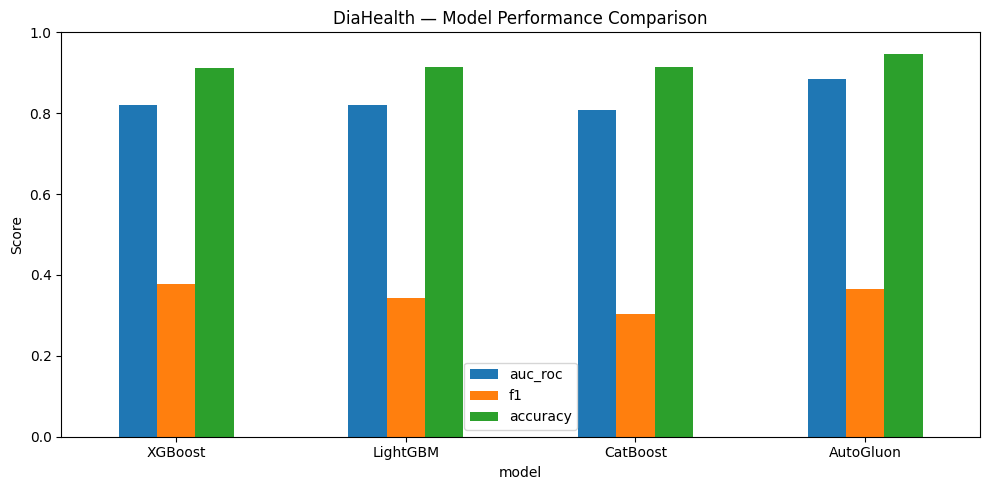

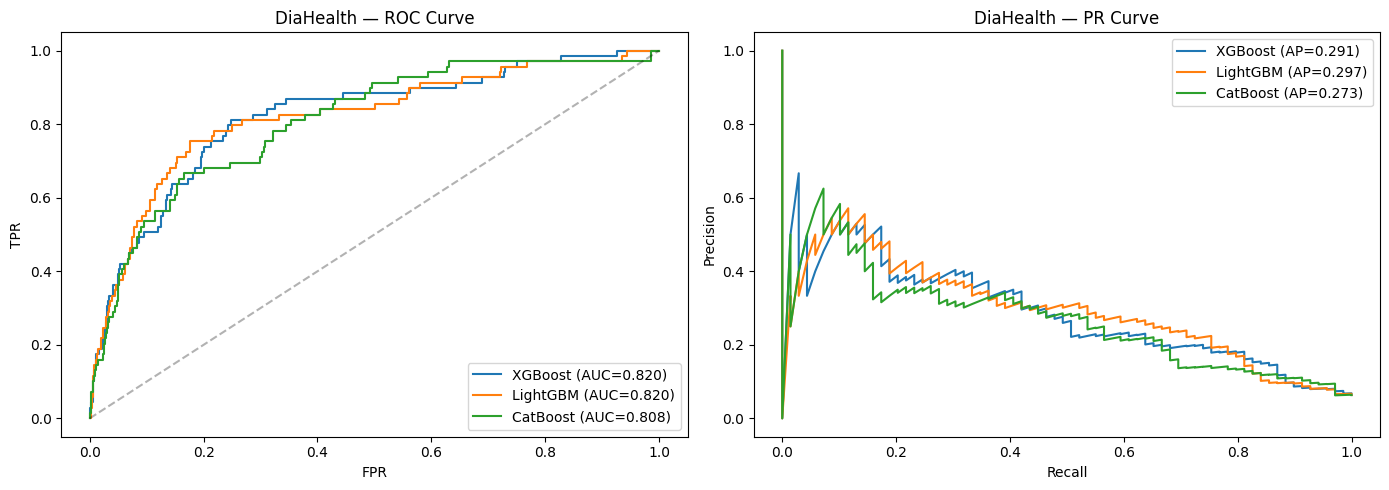

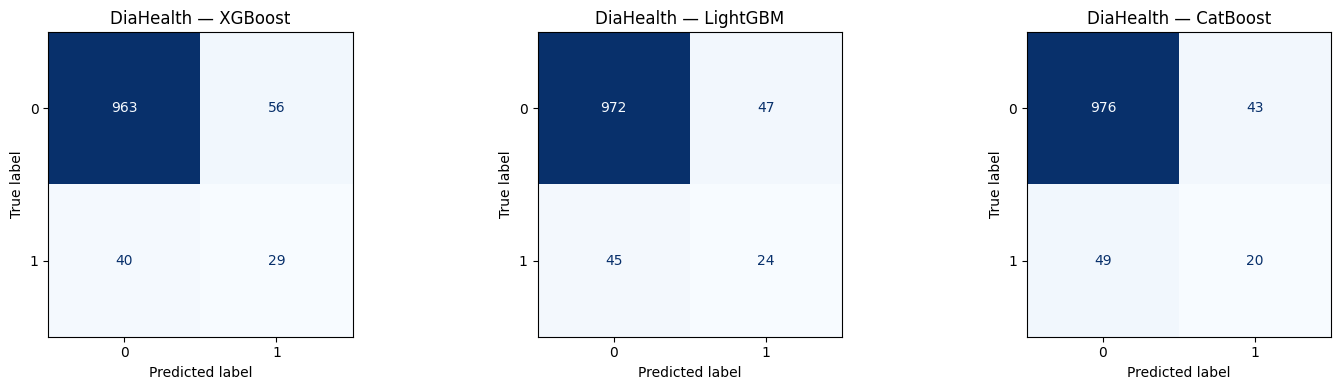

In [ ]:
# ============================================================
# 8. MODEL COMPARISON
# ============================================================
all_metrics = [xgb_metrics, lgb_metrics, cat_metrics, ag_metrics]
results_df  = pd.DataFrame(all_metrics)

print('\nModel Comparison — DiaHealth')
display(results_df[['model', 'accuracy', 'precision', 'recall',
                     'f1', 'auc_roc', 'auc_pr', 'brier']]
        .sort_values('auc_roc', ascending=False))

# Bar chart
results_df.set_index('model')[['auc_roc', 'f1', 'accuracy']].plot(
    kind='bar', figsize=(10, 5), rot=0)
plt.title('DiaHealth — Model Performance Comparison')
plt.ylabel('Score'); plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'model_comparison_bar.png'), dpi=150)
plt.show()

# ROC / PR curves (tree models only — AutoGluon handled separately)
plot_roc_pr({'XGBoost': xgb_model, 'LightGBM': lgb_model, 'CatBoost': cat_model},
            X_test, y_test)

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, [('XGBoost', xgb_model),
                                      ('LightGBM', lgb_model),
                                      ('CatBoost', cat_model)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X_test), ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'DiaHealth — {name}')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrices.png'), dpi=150)
plt.show()


## 9. Calibration Analysis

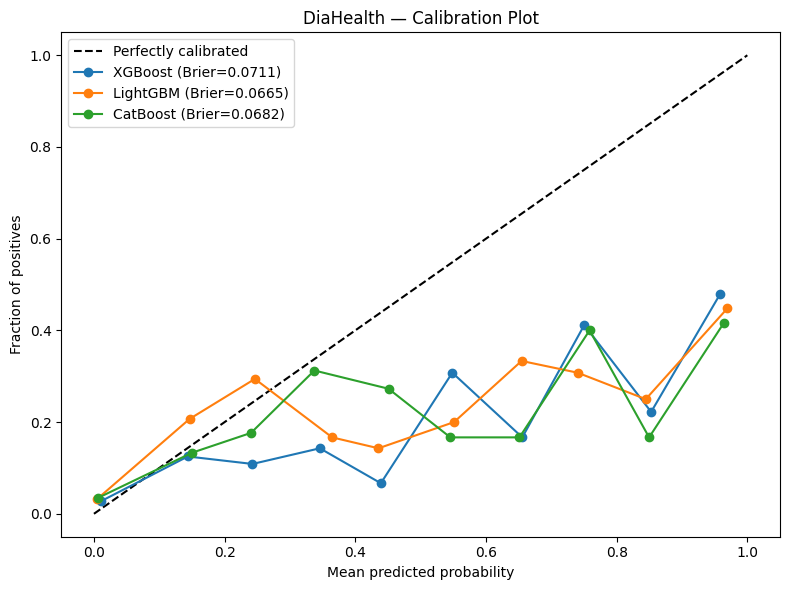

In [ ]:
# ============================================================
# 9. CALIBRATION ANALYSIS
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
for name, model in [('XGBoost', xgb_model), ('LightGBM', lgb_model), ('CatBoost', cat_model)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    frac, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    brier = brier_score_loss(y_test, y_prob)
    ax.plot(mean_pred, frac, marker='o', label=f'{name} (Brier={brier:.4f})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('DiaHealth — Calibration Plot')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration.png'), dpi=150)
plt.show()


## 10. Select Best Model & Save

In [ ]:
# ============================================================
# 10. SELECT BEST MODEL & SAVE
# ============================================================
best_row  = results_df.loc[results_df['auc_roc'].idxmax()]
best_name = best_row['model']
print(f'Best model: {best_name}  (AUC={best_row["auc_roc"]:.4f})')

model_map = {
    'XGBoost': xgb_model, 'LightGBM': lgb_model,
    'CatBoost': cat_model, 'AutoGluon': ag_model,
}

joblib.dump(xgb_model, os.path.join(MODELS_DIR, 'diahealth_xgboost.pkl'))
joblib.dump(lgb_model, os.path.join(MODELS_DIR, 'diahealth_lightgbm.pkl'))
joblib.dump(cat_model, os.path.join(MODELS_DIR, 'diahealth_catboost.pkl'))

best_info = {'diahealth': best_name}
joblib.dump(best_info, os.path.join(MODELS_DIR, 'best_model_info.pkl'))
results_df.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'), index=False)

print(f'\nAll models saved to {MODELS_DIR}')
print(f'Results saved to {RESULTS_DIR}')
print('Notebook 02 complete! Proceed to 03_xai.ipynb')


Best model: AutoGluon  (AUC=0.8858)

All models saved to /kaggle/working/exp_v2/models
Results saved to /kaggle/working/exp_v2/results
Notebook 02 complete! Proceed to 03_xai.ipynb
